# Test : Harmonic Mean for Gefitinib Concentration Profile

In this section, we will compare the concentration profiles generated from the same layered tissue conditions as in exp02_heterogenous_tissue.ipynb, but instead comparing two methods for calculating the half-cell diffusitivity values; $D_{i+\frac{1}{2}}$ and $D_{i-\frac{1}{2}}$.

In [2]:
# Baseline Method : Arithmetic mean from exp02_heterogenous_tissue.ipynb.

import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 5000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (D[i] + D[i-1]) / 2
        D_right = (D[i] + D[i+1]) / 2

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

C_arithmetic = np.array(saved_profiles)

# plt.figure(figsize=(8, 5))

# plt.imshow(

#     C_heatmap,

#     aspect='auto',

#     origin='lower',

#     extent=[0, L * 10, 0, T]

# )

# plt.colorbar(label='Relative Gefitinib Concentration')

# plt.xlabel('Depth (mm)')
# plt.ylabel('Time (s)')

# plt.title('Gefitinib Diffusion Through Heterogeneous Tumor Tissue')

# plt.axvline(boundary_1 * 10, linestyle='--')
# plt.axvline(boundary_2 * 10, linestyle='--')

# plt.savefig(
#     'figures/exp02_heterogeneous_heatmap.png',
#     dpi=150,
#     bbox_inches='tight'
# )

# plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
# plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
# plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

# plt.show()

In [3]:
# Refined Method : Harmonic mean.

import numpy as np
import matplotlib.pyplot as plt

# Parameters

# Tissue depth range (cm)
L = 0.2             # 2 mm

# Number of spatial points
nx = 200

x = np.linspace(0, L, nx)
dx = x[1] - x[0]

# Total simulation time (s)
T = 3600            # 1 hour

# Number of time steps
nt = 5000

dt = T / nt

# Layer boundaries (cm)
boundary_1 = 0.05   # 0.5 mm
boundary_2 = 0.12   # 1.2 mm

# Diffusion coefficients for each layer (cm^2/s)
D1 = 5e-7           # Outer tumor region
D2 = 1e-7           # Dense / diffusion-limited region
D3 = 5e-7           # Deeper tumor region

# Spatial diffusitivity profile
D = np.full(nx, D1)

D[x >= boundary_1] = D2
D[x >= boundary_2] = D3

# Constant drug source at vessel boundary
C_source = 1.0

# Saving buffer
save_every = 25

# Solving heterogenous profile

C = np.zeros(nx)
C[0] = C_source

saved_profiles = []

# Time-stepping loop
for t in range(nt):
    C_new = C.copy()

    for i in range(1, nx - 1):
        # diffusitivies
        D_left = (2 * D[i-1] * D[i]) / (D[i-1] + D[i])
        D_right = (2 * D[i] * D[i+1]) / (D[i] + D[i+1])

        # diffusion fluxes
        J_left = -D_left * (C[i] - C[i-1]) / dx
        J_right = -D_right * (C[i+1] - C[i]) / dx

        # update concentration
        C_new[i] = C[i] + (dt / dx) * (J_left - J_right)

    C = C_new

    # Re-apply source boundary condition
    C[0] = C_source

    if (t % save_every) == 0:
        saved_profiles.append(C.copy())

C_harmonic = np.array(saved_profiles)

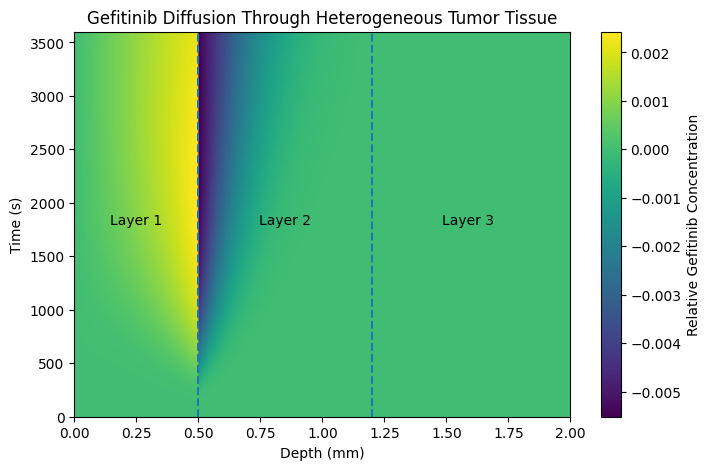

In [4]:
C_delta_heatmap = C_harmonic - C_arithmetic

plt.figure(figsize=(8, 5))

plt.imshow(

    C_delta_heatmap,

    aspect='auto',

    origin='lower',

    extent=[0, L * 10, 0, T]

)

plt.colorbar(label='Relative Gefitinib Concentration')

plt.xlabel('Depth (mm)')
plt.ylabel('Time (s)')

plt.title('Gefitinib Diffusion Through Heterogeneous Tumor Tissue')

plt.axvline(boundary_1 * 10, linestyle='--')
plt.axvline(boundary_2 * 10, linestyle='--')

plt.savefig(
    'figures/exp02_heterogeneous_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.annotate('Layer 1', xy=(boundary_1 * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 2', xy=((boundary_1 + boundary_2) * 5, T / 2), fontsize=10, ha='center')
plt.annotate('Layer 3', xy=((boundary_1 + boundary_2 + L) * 8.57 / 2, T / 2), fontsize=10, ha='center')

plt.show()

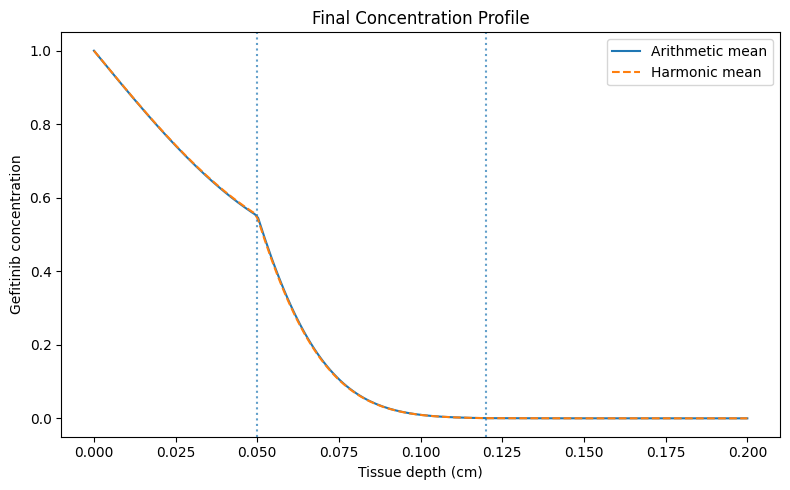

In [7]:
plt.figure(figsize=(8, 5))

C_arithmetic_final = C_arithmetic[-1]
C_harmonic_final = C_harmonic[-1]

plt.plot(x, C_arithmetic_final, label="Arithmetic mean")
plt.plot(x, C_harmonic_final, label="Harmonic mean", linestyle="--")

# Mark tissue interfaces
plt.axvline(boundary_1, linestyle=":", alpha=0.7)
plt.axvline(boundary_2, linestyle=":", alpha=0.7)

plt.xlabel("Tissue depth (cm)")
plt.ylabel("Gefitinib concentration")

plt.title("Final Concentration Profile")

plt.legend()
plt.tight_layout()
plt.show()

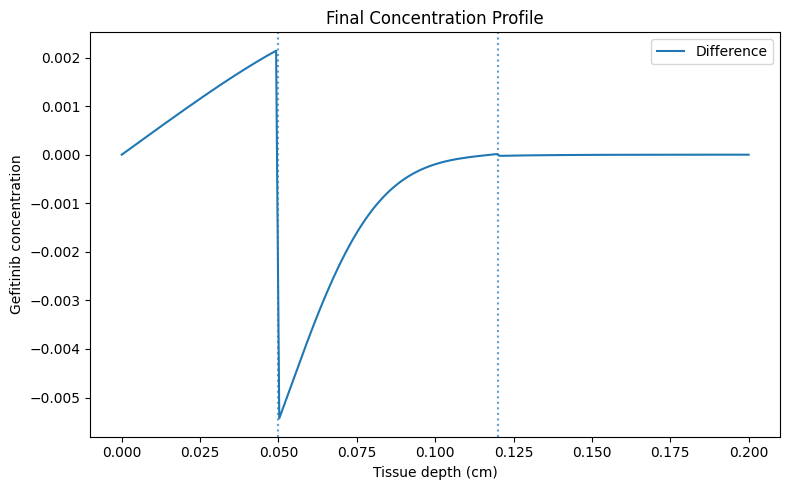

In [8]:
plt.figure(figsize=(8, 5))

C_difference = C_harmonic_final - C_arithmetic_final

plt.plot(x, C_difference, label="Difference")

# Mark tissue interfaces
plt.axvline(boundary_1, linestyle=":", alpha=0.7)
plt.axvline(boundary_2, linestyle=":", alpha=0.7)

plt.xlabel("Tissue depth (cm)")
plt.ylabel("Gefitinib concentration")

plt.title("Final Concentration Profile")

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
difference = C_harmonic_final - C_arithmetic_final

max_abs_difference = np.max(np.abs(difference))

relative_difference = (
    max_abs_difference /
    np.max(C_arithmetic_final)
) * 100

rmse = np.sqrt(
    np.mean(difference**2)
)

print(f"Maximum absolute difference: {max_abs_difference:.6f}")
print(f"Maximum difference (% of source concentration): {relative_difference:.3f}%")
print(f"RMSE: {rmse:.6f}")

Maximum absolute difference: 0.005428
Maximum difference (% of source concentration): 0.543%
RMSE: 0.001455
